In [10]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import random

In [2]:
import matplotlib as mpl

# Enable LaTeX-style font
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

# Random Classifier

## Preprocessing

In [3]:
# Validated Projected Monopartite Network
edge_np = np.load("../02_data/train_test/validated_edges.npy", allow_pickle=True)
edge_nodes = set(edge_np.flatten()) 

# Convert edge list numpy array to DataFrame
edge_list = pd.DataFrame(edge_np, columns=["source", "target"])

In [4]:
edge_list = pd.read_csv("../02_data/train_test/edge_list.csv")
edge_list.info()
edge_list.columns = ['source', 'target']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988982 entries, 0 to 1988981
Data columns (total 2 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   chat_id       int64 
 1   domain_index  object
dtypes: int64(1), object(1)
memory usage: 30.3+ MB


In [5]:
nodes = pd.read_csv("../02_data/train_test/node_features.csv")
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6106 entries, 0 to 6105
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain_id          6106 non-null   int64  
 1   url_index          6106 non-null   object 
 2   article            6106 non-null   object 
 3   domain             6106 non-null   object 
 4   article_embedding  6106 non-null   object 
 5   virality           6106 non-null   float64
 6   avalanches         6106 non-null   float64
 7   messages           6106 non-null   float64
 8   chats              6106 non-null   float64
 9   pc1                6106 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 477.2+ KB


In [6]:
train_data = pd.read_csv('../02_data/train_test/train_data.csv')
test_data = pd.read_csv('../02_data/train_test/test_data.csv')

In [7]:
print("edge_list info (train edges)")
print(edge_list.info())
print("-------------------------------------------------")

print("train_data info")
print(train_data.info())
print("-------------------------------------------------")

print("test_data info")
print(test_data.info())
print("-------------------------------------------------")

edge_list info (train edges)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988982 entries, 0 to 1988981
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   source  int64 
 1   target  object
dtypes: int64(1), object(1)
memory usage: 30.3+ MB
None
-------------------------------------------------
train_data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain             4884 non-null   object 
 1   url_index          4884 non-null   object 
 2   article            4884 non-null   object 
 3   article_embedding  4884 non-null   object 
 4   virality           4884 non-null   float64
 5   avalanches         4884 non-null   float64
 6   messages           4884 non-null   float64
 7   chats              4884 non-null   float64
 8   pc1                4884 non-null   float64
 9   domain_id        

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain             4884 non-null   object 
 1   url_index          4884 non-null   object 
 2   article            4884 non-null   object 
 3   article_embedding  4884 non-null   object 
 4   virality           4884 non-null   float64
 5   avalanches         4884 non-null   float64
 6   messages           4884 non-null   float64
 7   chats              4884 non-null   float64
 8   pc1                4884 non-null   float64
 9   domain_id          4884 non-null   int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 381.7+ KB


In [8]:
# Target labels
labels = pd.cut(train_data['pc1'], bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2])
train_data['label'] = pd.cut(train_data['pc1'], bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2])
test_data['label'] = pd.cut(test_data['pc1'], bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2])


#train_data["pc1_class"] = np.digitize(train_data["pc1"], bins=[0.33, 0.66])
#labels = torch.tensor(labels.values, dtype=torch.long)

## Random Classifier

weighing the classes by size 

In [11]:
temp = list(train_data.label)

N1=temp.count(0)
N2=temp.count(1)
N3=temp.count(2)
N=N1+N2+N3
N_test = len(test_data)
random_preds = [0 if random.random()<N1/N else 1 if random.random()<(N2+N1)/N else 2 for i in range(N_test)]


In [34]:
np.random.seed(42)  
#random_preds = np.random.randint(0, 3, size=len(test_data))

# --- Accuracy
acc = accuracy_score(test_data['label'], random_preds)
print(f"Random Classifier Accuracy: {acc:.4f}")

Random Classifier Accuracy: 0.3756


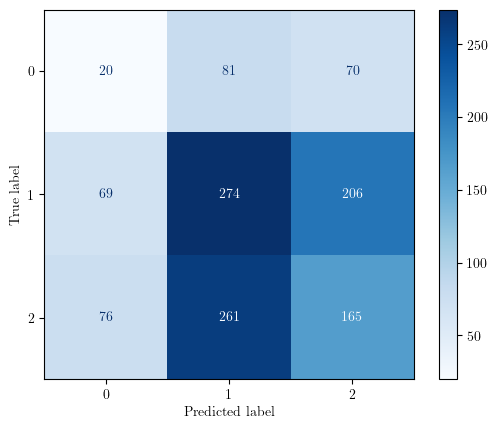

In [35]:
cm = confusion_matrix(test_data['label'], random_preds)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
#plt.title("Confusion Matrix (Random Classifier)")
plt.savefig(f'../03_plots/random_classifier/con_matrix_random.png')
plt.savefig(f'../03_plots/random_classifier/con_matrix_random.pdf')
plt.show()

In [36]:
y_true = test_data['label'].astype(int)

# Generate report
report = classification_report(y_true, random_preds)
print(report)

              precision    recall  f1-score   support

           0       0.12      0.12      0.12       171
           1       0.44      0.50      0.47       549
           2       0.37      0.33      0.35       502

    accuracy                           0.38      1222
   macro avg       0.31      0.31      0.31      1222
weighted avg       0.37      0.38      0.37      1222



In [ ]:
def random_classifier_fit(y_train):
    """
    Berechnet die Klassenverteilung aus den Trainingslabels.
    Rückgabe: (klassen_liste, gewichte_liste) – geeignet für random.choices
    """
    counts = Counter(y_train.values() if isinstance(y_train, dict) else y_train)
    classes, weights = zip(*sorted(counts.items()))
    return list(classes), [w for _, w in sorted(counts.items())]


def random_classifier_predict(n_items, classes, weights, seed=None):
    """
    Erzeugt n_items zufällige Labels nach der (trainierten) Klassenverteilung.
    """
    rng = random.Random(seed)
    return rng.choices(classes, weights=weights, k=n_items)

## Simple Network Classifier

In [12]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   domain             4884 non-null   object  
 1   url_index          4884 non-null   object  
 2   article            4884 non-null   object  
 3   article_embedding  4884 non-null   object  
 4   virality           4884 non-null   float64 
 5   avalanches         4884 non-null   float64 
 6   messages           4884 non-null   float64 
 7   chats              4884 non-null   float64 
 8   pc1                4884 non-null   float64 
 9   domain_id          4884 non-null   int64   
 10  label              4884 non-null   category
dtypes: category(1), float64(5), int64(1), object(4)
memory usage: 386.6+ KB


In [13]:
import networkx as nx
from collections import Counter
from sklearn.metrics import accuracy_score

In [14]:
valid_train_indices = set(train_data['domain_id'])
valid_test_indices = set(test_data['domain_id'])

node_mapping_train = {old_idx: new_idx for new_idx, old_idx in enumerate(sorted(valid_train_indices))}
node_mapping_test = {old_idx: new_idx for new_idx, old_idx in enumerate(sorted(valid_test_indices))}

# Reverse mapping 
# inv_node_mapping = {v: k for k, v in node_mapping.items()}

# Apply mapping to train and test data
train_data = train_data[train_data['domain_id'].isin(node_mapping_train)]
train_data['domain_id'] = train_data['domain_id'].map(node_mapping_train)

test_data = test_data[test_data['domain_id'].isin(node_mapping_test)]
test_data['domain_id'] = test_data['domain_id'].map(node_mapping_test)

edge_list_filtered = edge_list[
    edge_list['source'].isin(node_mapping_train) & edge_list['target'].isin(node_mapping_train)
]
edge_list_mapped = edge_list_filtered.replace(node_mapping_train)

G = nx.from_pandas_edgelist(edge_list_mapped, source='source', target='target')

missing_nodes = train_data[~train_data['domain_id'].isin(G.nodes)]
print(f"Train nodes missing from graph: {len(missing_nodes)}")

missing_nodes = test_data[~test_data['domain_id'].isin(G.nodes)]
print(f"Test nodes missing from graph: {len(missing_nodes)}")

Train nodes missing from graph: 4884
Test nodes missing from graph: 1222


In [50]:
G = nx.from_pandas_edgelist(edge_list, source='source', target='target')

G.add_nodes_from(nodes['domain_id'])

In [52]:
train_nodes = list(train_data["domain_id"])
test_nodes = list(test_data["domain_id"])

taking the raw scores, and take the mean, make classes after prediction
random structure

In [54]:
# Create label dictionary using new node indices
label_dict = dict(zip(test_data['domain_id'], test_data['label']))

#print(G.nodes)

# Predict by majority vote of neighbors
fallback_count = 0
def predict_label_by_neighbors(node_id):
    neighbors = list(G.neighbors(node_id))
    #print(node_id)
    #print(neighbors)
    neighbor_labels = [label_dict[n] for n in neighbors if n in label_dict]
    #print(neighbor_labels)
    if neighbor_labels:
        return Counter(neighbor_labels).most_common(1)[0][0]
    else:
        global fallback_count
        fallback_count += 1
        return np.random.randint(0, 3)

# Predict for test nodes
test_data['predicted_label'] = test_data['domain_id'].apply(predict_label_by_neighbors)
#print("Fallback predictions (no labeled neighbors):", fallback_count)

In [55]:
acc = accuracy_score(test_data['label'], test_data['predicted_label'])
print(f"Network-Based Classifier Accuracy: {acc:.4f}")

Network-Based Classifier Accuracy: 0.3290


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Sample: draw a small subgraph for clarity
random.seed(42)

# Sample 100 nodes randomly from the graph
subgraph_nodes = random.sample(list(G.nodes), k=1000)

H = G.subgraph(subgraph_nodes)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(H, seed=42)  # layout with fixed seed for reproducibility

# Draw nodes with color if labels are available
node_colors = ['skyblue' if n in label_dict else 'lightgray' for n in H.nodes]
nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=300, alpha=0.8)
nx.draw_networkx_edges(H, pos, alpha=0.4)
nx.draw_networkx_labels(H, pos, font_size=8)

plt.title("Subgraph Visualization (First 100 Nodes)")
plt.axis('off')
plt.tight_layout()
plt.show()


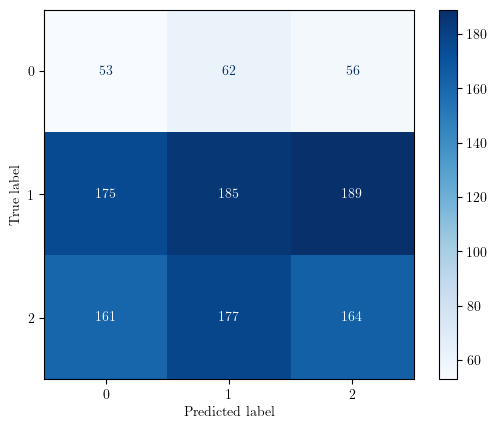

In [57]:
cm = confusion_matrix(test_data['label'], test_data['predicted_label'])

# Display it with labels and color
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')  # You can also try 'Oranges', 'viridis', etc.
# plt.title("Confusion Matrix (Network-Based Classifier)")
plt.savefig(f'../03_plots/random_classifier/con_matrix_network.png')
plt.savefig(f'../03_plots/random_classifier/con_matrix_network.pdf')
plt.show()

In [58]:
y_true = test_data['label'].astype(int)
y_pred = test_data['predicted_label'].astype(int)

# Generate report
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.14      0.31      0.19       171
           1       0.44      0.34      0.38       549
           2       0.40      0.33      0.36       502

    accuracy                           0.33      1222
   macro avg       0.32      0.32      0.31      1222
weighted avg       0.38      0.33      0.35      1222



In [ ]:
# --- Simple Network Classifier (Mehrheitslabel der trainierten Nachbarn)
net_preds = simple_network_classifier_predict(
    G, train_labels, test_nodes, seed=42, fallback_to_random=True
)
print("Simple Network Classifier:", net_preds)